In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere
from metrics import evaluate_conformality

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

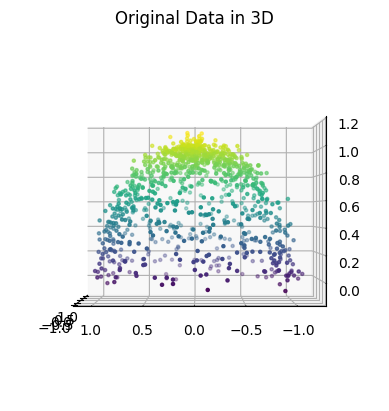

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [6]:
lambda_isos = np.logspace(-3, 2, 10)

In [ ]:
num_epochs = 100
# train same model multiple times to average results
num_models = 4

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = f"models/conformal_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_{j+1}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00113540, Reconstruction Loss: 0.00104988, Conformal Loss: 0.08552217
Epoch [100/100], Validation Loss: 0.00131953, Reconstruction Loss: 0.00123235, Conformal Loss: 0.08717929
Model 1/4 with lambda_iso=0.001 trained and saved.
Training model 2/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00106244, Reconstruction Loss: 0.00098790, Conformal Loss: 0.07453142
Epoch [100/100], Validation Loss: 0.00129009, Reconstruction Loss: 0.00120811, Conformal Loss: 0.08197548
Model 2/4 with lambda_iso=0.001 trained and saved.
Training model 3/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00113805, Reconstruction Loss: 0.00105599, Conformal Loss: 0.08206609
Epoch [100/100], Validation Loss: 0.00136706, Reconstruction Loss: 0.00126491, Conformal Loss: 0.10215171
Model 3/4 with lambda_iso=0.001 trained and saved.
Training model 4/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00122924, Reconstruction Loss: 0.00113028, Conformal Lo

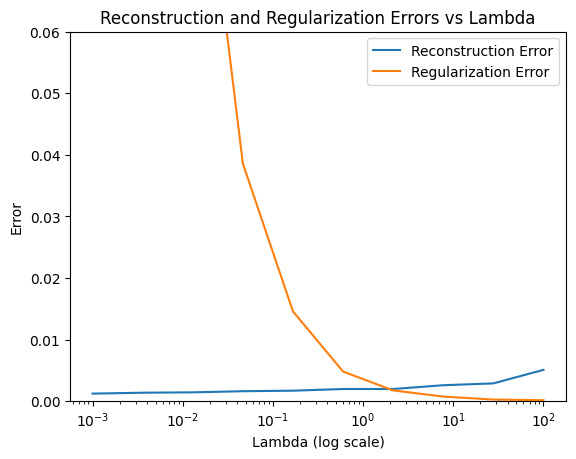

In [11]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(0, 0.06)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

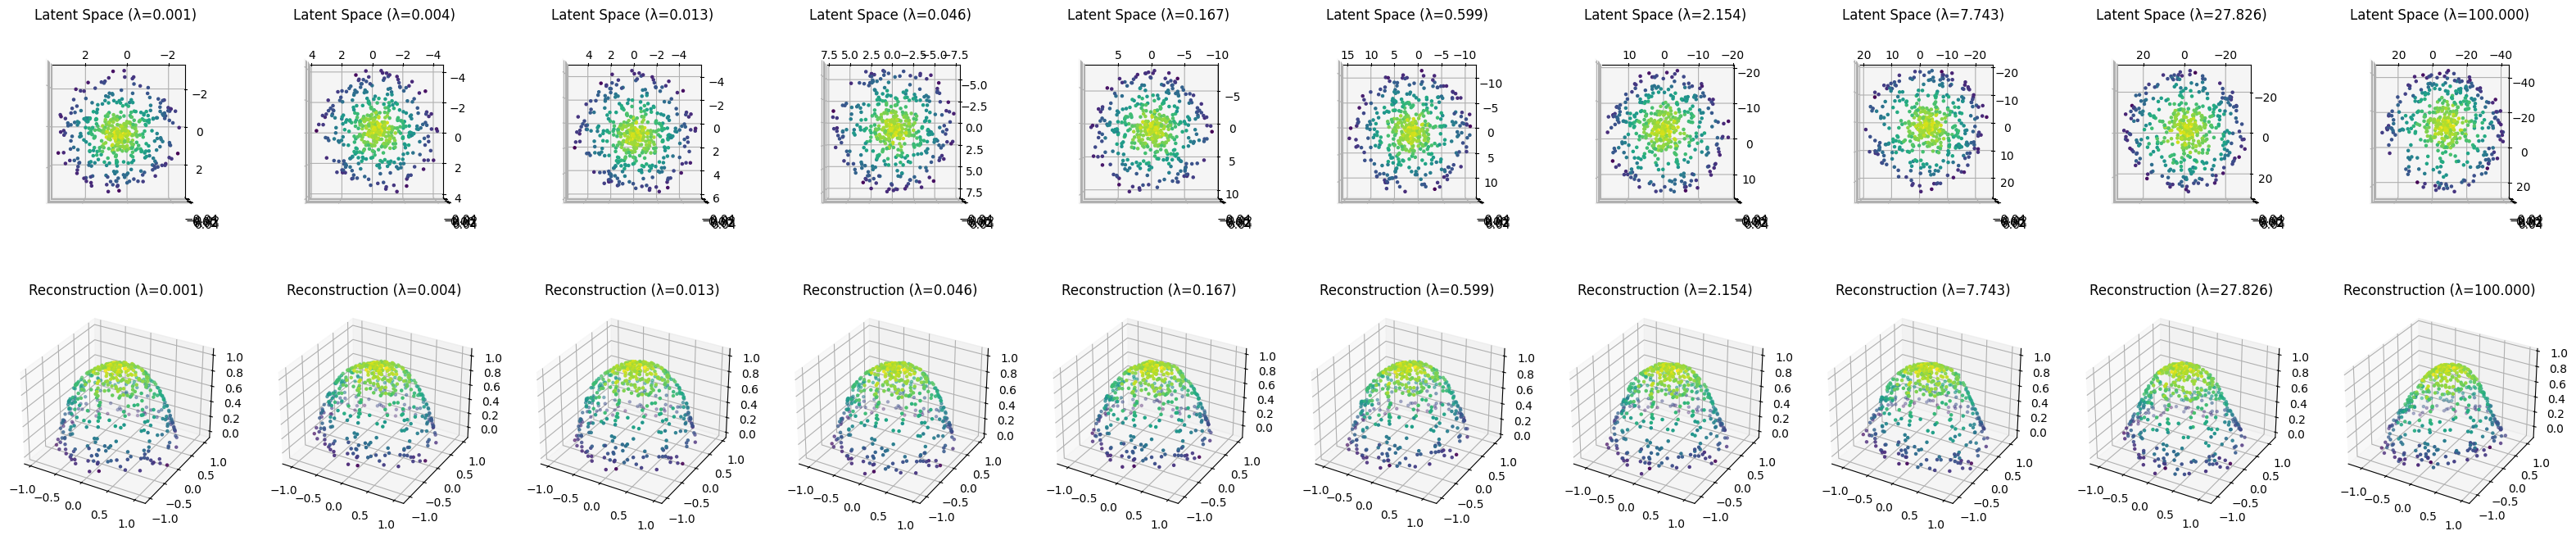

In [14]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_2.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=val_labels, s=5)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=val_labels, s=5)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

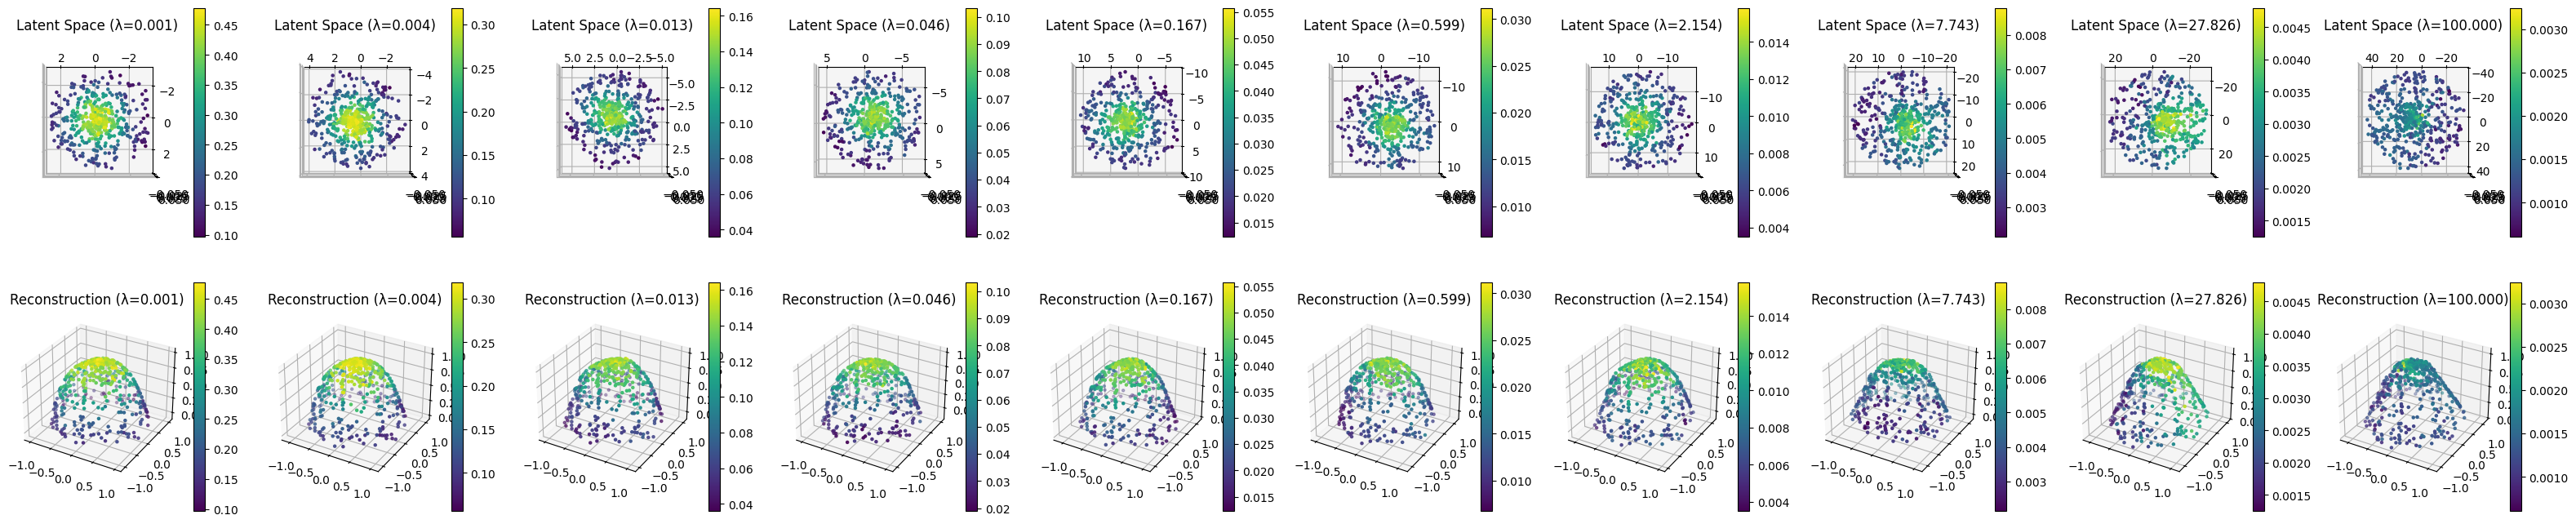

In [ ]:
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        trace_JtJ = torch.trace(JtJ)

        # Store the trace value as a label for the point
        trace_vals[j] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

    p = axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    p = axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

In [7]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)


    # print("lambda: ", lambda_iso)
    statses.append(evaluate_conformality(model, data))
    # print("Conformality Statistics:")
    # for key, value in stats.items():
    #     print(f"{key}: {value.item():.4f}")
    # print("Reconstruction Error:")
    # print(torch.nn.MSELoss()(data, model(data)).item())
    # print("_" *50)

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

# styled_df

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [8]:
def highlight_best_and_worst(s, best='max'):
    if best == 'max':
        best_val = s.max()
        worst_val = s.min()
    else:
        best_val = s.min()
        worst_val = s.max()
    
    return [
        'background-color: green' if v == best_val else
        'background-color: red' if v == worst_val else ''
        for v in s
    ]

styled_df = df.style \
    .apply(highlight_best_and_worst, best='min', subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            ]) \
    .apply(highlight_best_and_worst, best='max', subset=[
        'determinant_vs_estimate_mean'
    ])

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.001000,0.001006,0.049044,0.319400,0.113487,0.355313,0.007599,0.021494,0.028342,0.080164,0.014345,0.031791,0.052864,0.117354,0.994722,0.008314,1.079443,1.092179,1.066707,49.051800
0.003594,0.001114,0.051179,0.215430,0.078330,0.363601,0.004385,0.012404,0.024417,0.069063,0.008806,0.019565,0.050007,0.111415,0.994717,0.009337,1.335174,1.341950,1.328398,61.016579
0.012915,0.001046,0.054742,0.103715,0.036099,0.348064,0.002797,0.007912,0.032550,0.092066,0.005155,0.011534,0.059921,0.133963,0.992619,0.013104,1.912822,1.931871,1.893772,87.958931
0.046416,0.001630,0.060428,0.064691,0.022476,0.347437,0.001531,0.004330,0.028497,0.080602,0.003128,0.006974,0.058711,0.130904,0.992760,0.012745,2.436405,2.443812,2.428998,117.327293
0.166810,0.001476,0.058045,0.035028,0.012095,0.345300,0.001056,0.002987,0.036502,0.103244,0.001931,0.004304,0.065525,0.146004,0.991601,0.012786,3.328847,3.335164,3.322531,158.946091
0.599484,0.001591,0.069918,0.019225,0.006475,0.336791,0.000602,0.001703,0.037429,0.105866,0.001169,0.002595,0.072389,0.161120,0.989082,0.020506,4.533048,4.580993,4.485103,215.029617
2.154435,0.002051,0.073978,0.009855,0.003092,0.313728,0.000318,0.000900,0.037611,0.106379,0.000638,0.001416,0.074600,0.165453,0.988779,0.021129,6.104976,6.183963,6.025989,272.647278
7.742637,0.002069,0.089784,0.005188,0.001425,0.274592,0.000235,0.000663,0.050902,0.143973,0.000441,0.000982,0.095795,0.213270,0.982317,0.027758,8.386324,8.478532,8.294115,384.067322
27.825594,0.002267,0.102262,0.003291,0.000905,0.275139,0.000128,0.000363,0.045776,0.129474,0.000273,0.000600,0.096907,0.213140,0.978766,0.052231,10.593352,10.681009,10.505695,515.597107
100.000000,0.002292,0.118403,0.001499,0.000361,0.241112,0.000089,0.000252,0.064736,0.183100,0.000173,0.000387,0.123939,0.277204,0.969818,0.051095,15.530098,15.636331,15.423864,732.473999


In [13]:
styled = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')  # Reversed: lower = greener

styled

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.001000,0.001006,0.049044,0.319400,0.113487,0.355313,0.007599,0.021494,0.028342,0.080164,0.014345,0.031791,0.052864,0.117354,0.994722,0.008314,1.079443,1.092179,1.066707,49.051800
0.003594,0.001114,0.051179,0.215430,0.078330,0.363601,0.004385,0.012404,0.024417,0.069063,0.008806,0.019565,0.050007,0.111415,0.994717,0.009337,1.335174,1.341950,1.328398,61.016579
0.012915,0.001046,0.054742,0.103715,0.036099,0.348064,0.002797,0.007912,0.032550,0.092066,0.005155,0.011534,0.059921,0.133963,0.992619,0.013104,1.912822,1.931871,1.893772,87.958931
0.046416,0.001630,0.060428,0.064691,0.022476,0.347437,0.001531,0.004330,0.028497,0.080602,0.003128,0.006974,0.058711,0.130904,0.992760,0.012745,2.436405,2.443812,2.428998,117.327293
0.166810,0.001476,0.058045,0.035028,0.012095,0.345300,0.001056,0.002987,0.036502,0.103244,0.001931,0.004304,0.065525,0.146004,0.991601,0.012786,3.328847,3.335164,3.322531,158.946091
0.599484,0.001591,0.069918,0.019225,0.006475,0.336791,0.000602,0.001703,0.037429,0.105866,0.001169,0.002595,0.072389,0.161120,0.989082,0.020506,4.533048,4.580993,4.485103,215.029617
2.154435,0.002051,0.073978,0.009855,0.003092,0.313728,0.000318,0.000900,0.037611,0.106379,0.000638,0.001416,0.074600,0.165453,0.988779,0.021129,6.104976,6.183963,6.025989,272.647278
7.742637,0.002069,0.089784,0.005188,0.001425,0.274592,0.000235,0.000663,0.050902,0.143973,0.000441,0.000982,0.095795,0.213270,0.982317,0.027758,8.386324,8.478532,8.294115,384.067322
27.825594,0.002267,0.102262,0.003291,0.000905,0.275139,0.000128,0.000363,0.045776,0.129474,0.000273,0.000600,0.096907,0.213140,0.978766,0.052231,10.593352,10.681009,10.505695,515.597107
100.000000,0.002292,0.118403,0.001499,0.000361,0.241112,0.000089,0.000252,0.064736,0.183100,0.000173,0.000387,0.123939,0.277204,0.969818,0.051095,15.530098,15.636331,15.423864,732.473999


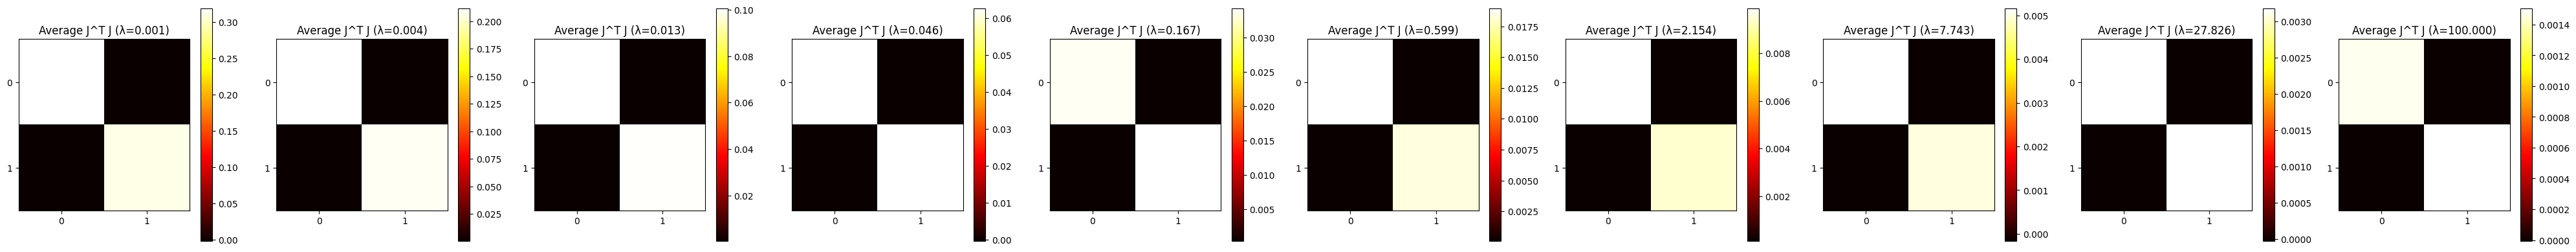

In [19]:
fig, axs = plt.subplots(1, 10, figsize=(40, 4))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        JtJs += JtJ
    JtJs /= len(encoded_data)  # Average over all points

    p = axs[i].imshow(JtJs.cpu().numpy(), cmap='hot')
    plt.colorbar(p)
    axs[i].set_title(f'Average J^T J (λ={lambda_iso:.3f})')
    axs[i].set_xticks(range(latent_dim))
    axs[i].set_yticks(range(latent_dim))
plt.tight_layout()
plt.show()

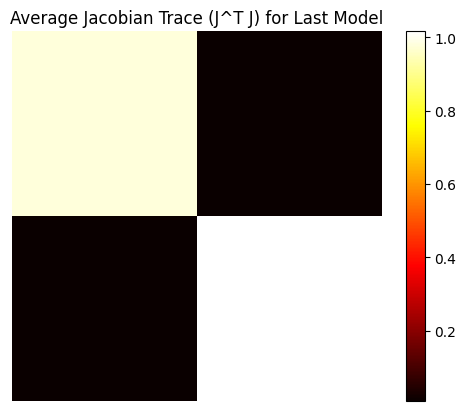

In [17]:
model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_isos[-1]:.3f}_model_3.pth"
model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_isos[-1]).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data = model.encode(val_data[:1000])
    reconstruction = model.decode(encoded_data)

JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
for i, z in enumerate(encoded_data):
    z = z.unsqueeze(0)  # Add batch dimension

    J = torch.autograd.functional.jacobian(model.decoder, z)[0,:,0,:]
    JtJ = J.transpose(0, 1) @ J
    JtJs += JtJ

JtJs /= encoded_data.shape[0]  # Average over all points

plt.imshow(JtJs.cpu().numpy(), cmap='hot')
plt.colorbar()
plt.title('Average Jacobian Trace (J^T J) for Last Model')
plt.axis('off')
plt.show()

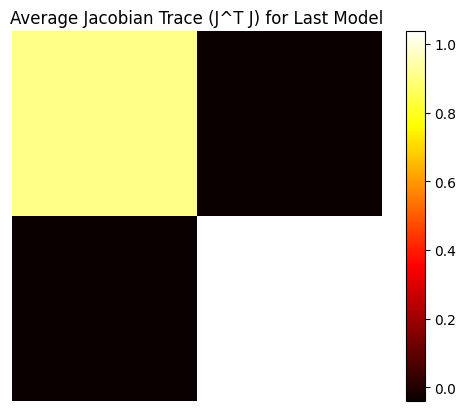

In [13]:
model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_isos[0]:.3f}_model_3.pth"
model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_isos[0]).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data = model.encode(val_data[:1000])
    reconstruction = model.decode(encoded_data)

JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
for i, z in enumerate(encoded_data):
    z = z.unsqueeze(0)  # Add batch dimension

    J = torch.autograd.functional.jacobian(model.decoder, z)[0,:,0,:]
    JtJ = J.transpose(0, 1) @ J
    JtJs += JtJ

JtJs /= encoded_data.shape[0]  # Average over all points

plt.imshow(JtJs.cpu().numpy(), cmap='hot')
plt.colorbar()
plt.title('Average Jacobian Trace (J^T J) for Last Model')
plt.axis('off')
plt.show()

In [19]:
def diagonality_loss(func, z):
    device = z.device
    losses = []
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = func(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(func, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J

        eye = torch.eye(JtJ.size(0), device=device)
        off_diag_mask = 1.0 - eye
        off_diag_elements = JtJ[off_diag_mask.bool()]
        loss_matrix = off_diag_elements ** 2

        losses.append(loss_matrix.mean().item())
    
    return np.mean(losses).item()

In [20]:
# measure isometry, scaled isometry, conformity, diagonality, (angle preservation, kl)
from metrics import isometry_loss, scaled_isometry_loss, conformality_loss

for i, lambda_iso in enumerate(lambda_isos):
    print(f"Evaluating model with lambda_iso={lambda_iso:.3f}")
    model_path = f"models/isometric_autoencoder_half_sphere/isometric_autoencoder_half_sphere_lambda_{lambda_iso:.3f}_model_3.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    isometry = isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    scaled_isometry = scaled_isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    conformality = conformality_loss(model.decoder, encoded_data)
    diagonality = diagonality_loss(model.decoder, encoded_data)
    print(f"Isometry Loss: {isometry.item()}")
    print(f"Scaled Isometry Loss: {scaled_isometry.item()}")
    print(f"Conformality Loss: {conformality.item()}")
    print(f"Diagonality Loss: {diagonality}")
    print("-" * 50)

Evaluating model with lambda_iso=0.001
Isometry Loss: 0.029118411242961884
Scaled Isometry Loss: 0.6169936060905457
Conformality Loss: 45.173675537109375
Diagonality Loss: 0.025357555102318588
--------------------------------------------------
Evaluating model with lambda_iso=0.004
Isometry Loss: 0.017929190769791603
Scaled Isometry Loss: 0.5752668380737305
Conformality Loss: 34.43684387207031
Diagonality Loss: 0.017241241908394104
--------------------------------------------------
Evaluating model with lambda_iso=0.013
Isometry Loss: 0.011385654099285603
Scaled Isometry Loss: 0.5312831401824951
Conformality Loss: 42.44587707519531
Diagonality Loss: 0.021127933980045942
--------------------------------------------------
Evaluating model with lambda_iso=0.046
Isometry Loss: 0.01075800135731697
Scaled Isometry Loss: 0.5652207732200623
Conformality Loss: 37.75851821899414
Diagonality Loss: 0.01960496960456461
--------------------------------------------------
Evaluating model with lambda_